<a href="https://colab.research.google.com/github/DaniBsz/Analisis-exploratorio-de-datos/blob/main/Analisis_y_Graficaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cargar biblioteca
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATOS CARGADOS

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [6]:
df = sns.load_dataset("healthexp")

In [7]:
df.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             274 non-null    int64  
 1   Country          274 non-null    object 
 2   Spending_USD     274 non-null    float64
 3   Life_Expectancy  274 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 8.7+ KB


In [17]:
#Evaluar el tipo de variable
print(df.Spending_USD.dtype)
print(df.Year.dtype)
print(df.Life_Expectancy.dtype)
print(df.Country.dtype)

float64
int64
float64
object


In [18]:
df.describe()

,Year,Spending_USD,Life_Expectancy
count,274.000000,274.000000,274.000000
mean,1996.992701,2789.338905,77.909489
std,14.180933,2194.939785,3.276263
min,1970.000000,123.993000,70.600000
25%,1985.250000,1038.357000,75.525000
50%,1998.000000,2295.578000,78.100000
75%,2009.000000,4055.610000,80.575000
max,2020.000000,11859.179000,84.700000


In [23]:
df.shape

(274, 4)

Calcular metricas especificas

In [24]:
resumen = df.groupby('Country').agg(
    Año_Inicial=('Year', 'min'),
    Año_Final=('Year', 'max'),
    Gasto_Promedio_USD=('Spending_USD', 'mean'),
    Esperanza_Vida_Promedio=('Life_Expectancy', 'mean')
).reset_index()

In [25]:
resumen['Gasto_Promedio_USD'] = resumen['Gasto_Promedio_USD'].round(2)
resumen['Esperanza_Vida_Promedio'] = resumen['Esperanza_Vida_Promedio'].round(1)

In [26]:
display(resumen)

,Country,Año_Inicial,Año_Final,Gasto_Promedio_USD,Esperanza_Vida_Promedio
0,Canada,1971,2020,2685.78,78.7
1,France,1970,2020,3045.15,79.6
2,Germany,1970,2020,2667.28,76.7
3,Great Britain,1970,2020,2034.19,77.6
4,Japan,1970,2020,1860.26,79.6
5,USA,1970,2020,4388.57,75.8


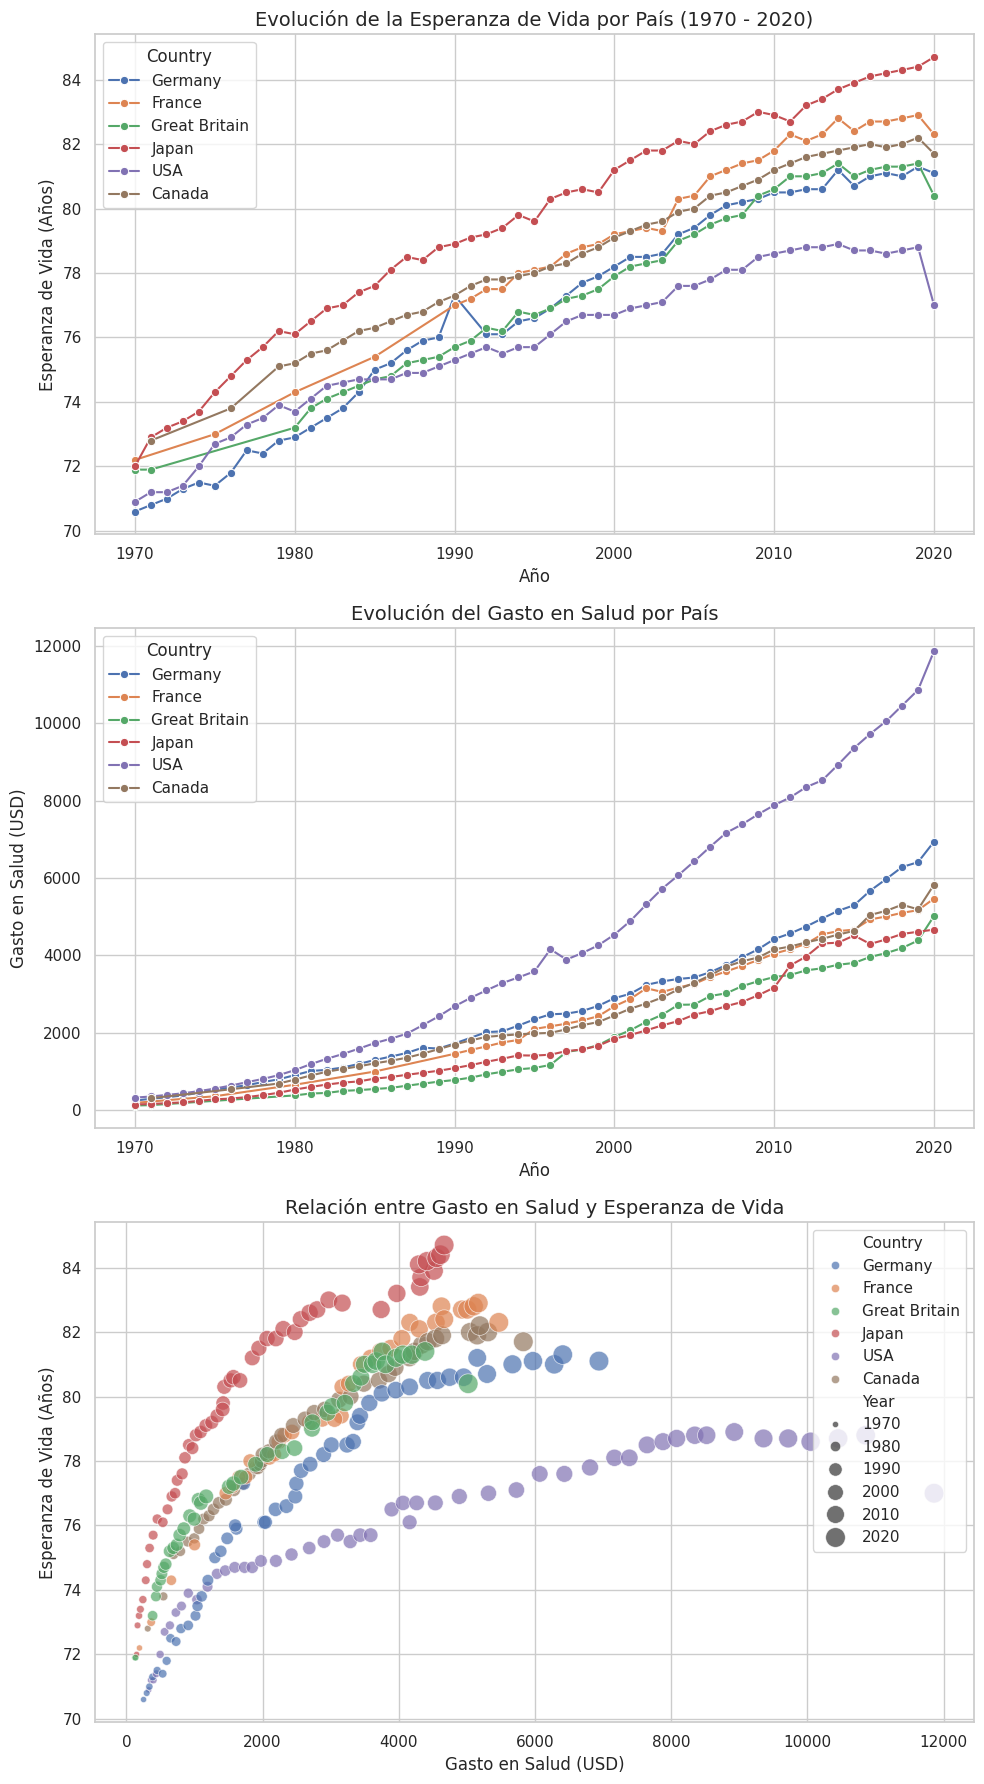

In [27]:
sns.set_theme(style="whitegrid")

# figura con 3 subgráficos
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# Evolución de la Esperanza de Vida a lo largo del tiempo
sns.lineplot(
    data=df,
    x="Year",
    y="Life_Expectancy",
    hue="Country",
    marker="o",
    ax=axes[0]
)
axes[0].set_title('Evolución de la Esperanza de Vida por País (1970 - 2020)', fontsize=14)
axes[0].set_ylabel('Esperanza de Vida (Años)')
axes[0].set_xlabel('Año')

# Evolución del Gasto en Salud (USD) a lo largo del tiempo
sns.lineplot(
    data=df,
    x="Year",
    y="Spending_USD",
    hue="Country",
    marker="o",
    ax=axes[1]
)
axes[1].set_title('Evolución del Gasto en Salud por País', fontsize=14)
axes[1].set_ylabel('Gasto en Salud (USD)')
axes[1].set_xlabel('Año')

# Relación entre Gasto en Salud y Esperanza de Vida
sns.scatterplot(
    data=df,
    x="Spending_USD",
    y="Life_Expectancy",
    hue="Country",
    size="Year", # Los puntos más grandes son años más recientes
    sizes=(20, 200),
    alpha=0.7,
    ax=axes[2]
)
axes[2].set_title('Relación entre Gasto en Salud y Esperanza de Vida', fontsize=14)
axes[2].set_xlabel('Gasto en Salud (USD)')
axes[2].set_ylabel('Esperanza de Vida (Años)')

plt.tight_layout()
plt.show()

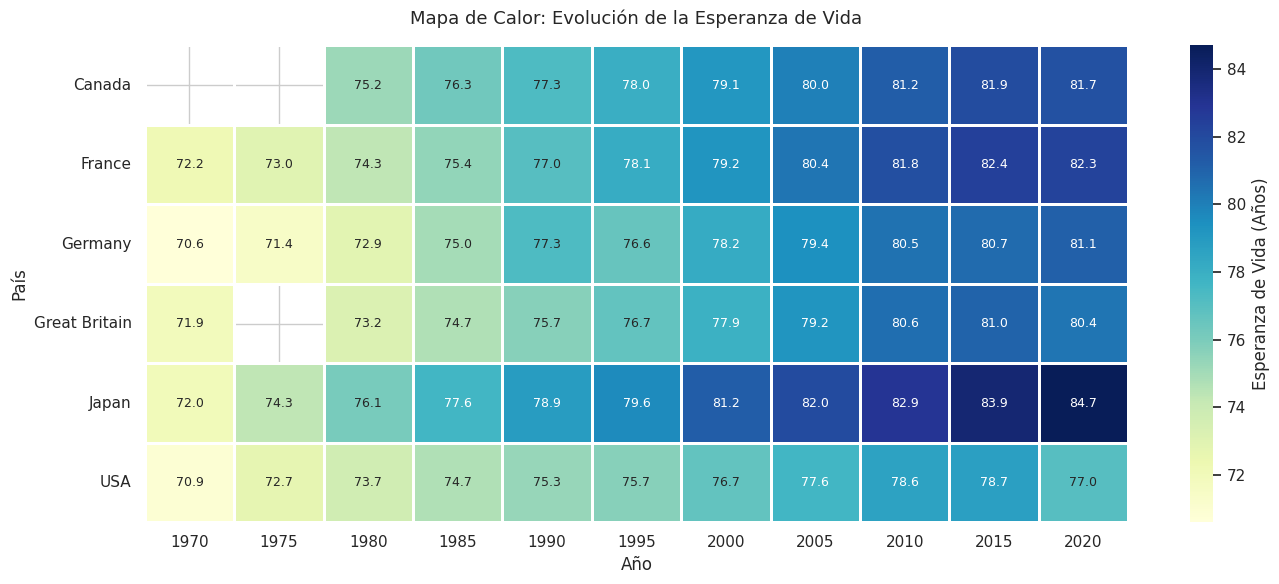

In [35]:
pivot_filtrado = pivot_df.iloc[:, ::5]

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot_filtrado,
    cmap="YlGnBu",
    annot=True,
    fmt=".1f",
    linewidths=0.8,
    annot_kws={"size": 9},
    cbar_kws={"label": "Esperanza de Vida (Años)"},
)

plt.title("Mapa de Calor: Evolución de la Esperanza de Vida", fontsize=13, pad=15)
plt.xlabel("Año")
plt.ylabel("País")
plt.tight_layout()
plt.show()

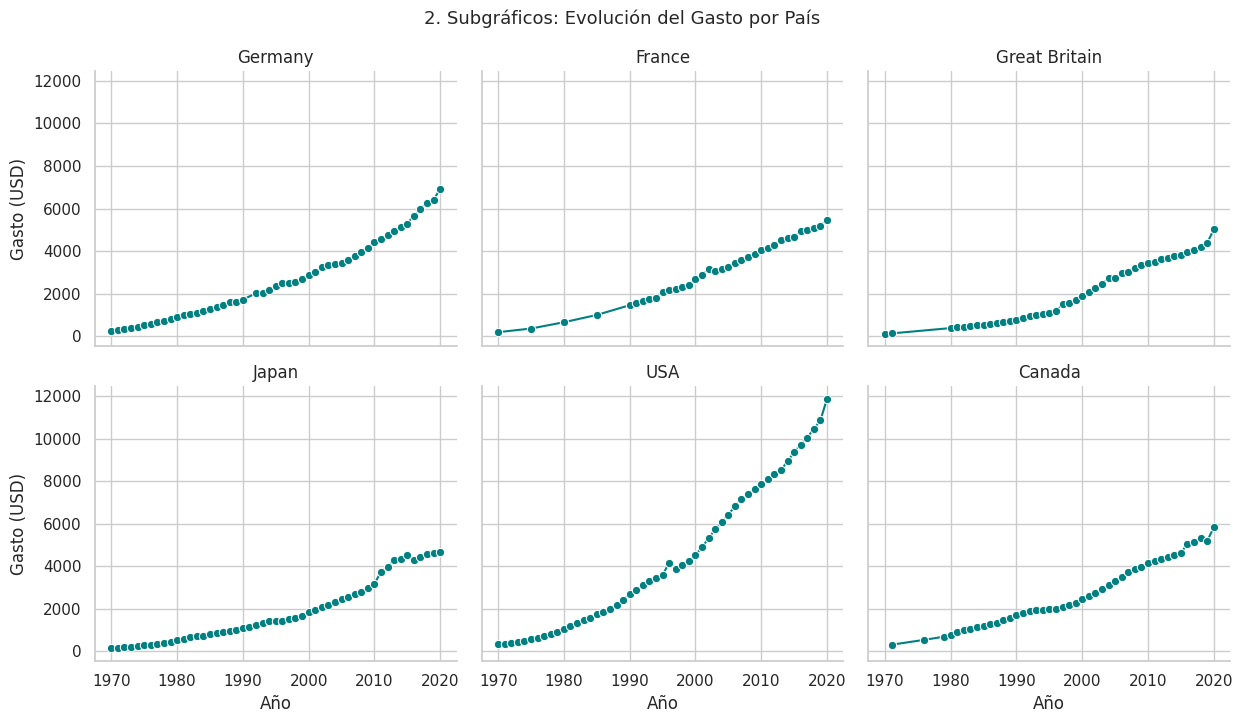

In [31]:
g = sns.FacetGrid(df, col="Country", col_wrap=3, height=3.5, aspect=1.2)
g.map_dataframe(sns.lineplot, x="Year", y="Spending_USD", color="teal", marker="o")
g.set_axis_labels("Año", "Gasto (USD)")
g.set_titles(col_template="{col_name}")
g.fig.suptitle(
    "2. Subgráficos: Evolución del Gasto por País", fontsize=13, y=1.03
)
plt.show()

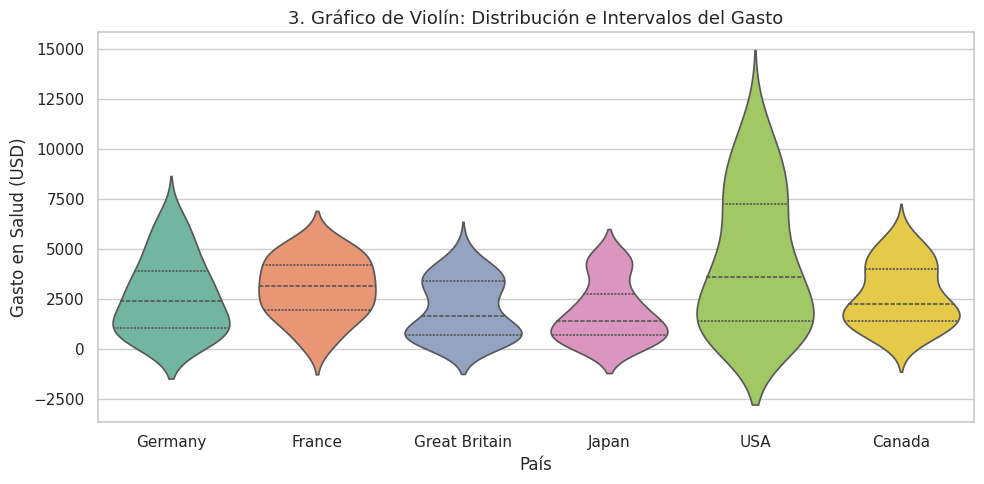

In [32]:
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x="Country",
    y="Spending_USD",
    hue="Country",
    palette="Set2",
    inner="quartile",
    legend=False,
)
plt.title("3. Gráfico de Violín: Distribución e Intervalos del Gasto", fontsize=13)
plt.xlabel("País")
plt.ylabel("Gasto en Salud (USD)")
plt.tight_layout()
plt.show()

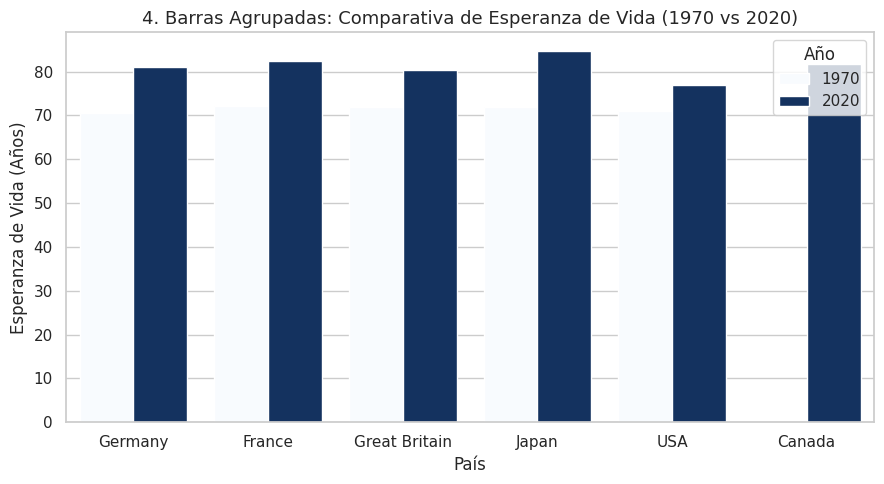

In [33]:
min_year, max_year = df["Year"].min(), df["Year"].max()
df_hitos = df[df["Year"].isin([min_year, max_year])]

plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_hitos,
    x="Country",
    y="Life_Expectancy",
    hue="Year",
    palette="Blues",
)
plt.title(
    f"4. Barras Agrupadas: Comparativa de Esperanza de Vida ({min_year} vs {max_year})",
    fontsize=13,
)
plt.xlabel("País")
plt.ylabel("Esperanza de Vida (Años)")
plt.legend(title="Año")
plt.tight_layout()
plt.show()

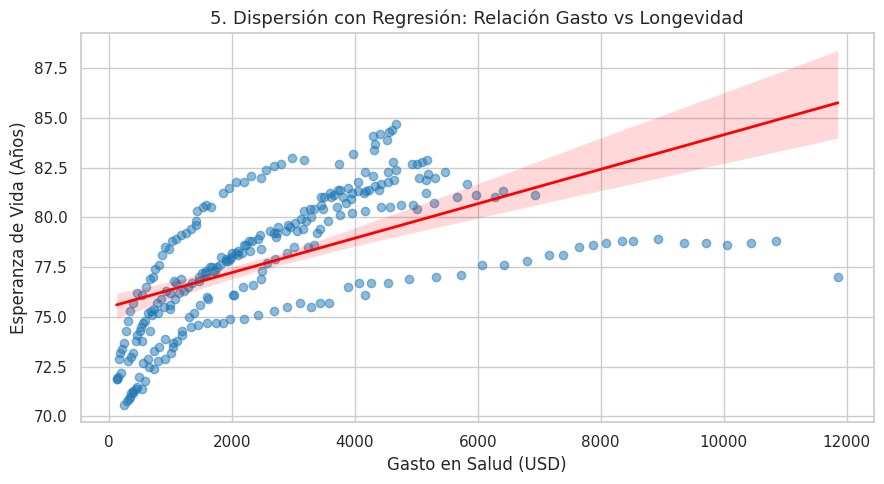

In [34]:
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df,
    x="Spending_USD",
    y="Life_Expectancy",
    scatter_kws={"alpha": 0.5, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2},
)
plt.title("5. Dispersión con Regresión: Relación Gasto vs Longevidad", fontsize=13)
plt.xlabel("Gasto en Salud (USD)")
plt.ylabel("Esperanza de Vida (Años)")
plt.tight_layout()
plt.show()

*STORYTELLING*

Si miramos los datos de 1970, el punto de partida es bastante parejo. Países como Francia, Alemania, Japón y EE. UU. andaban todos por los 70 o 72 años de esperanza de vida. Y eso que, como vimos con los huecos en el gráfico, en esa época ni siquiera se medía todo con la misma rigurosidad. La idea general en ese entonces era muy lineal: si se le metía más plata al sistema de salud, la gente iba a vivir más.

El caso de Japón es de manual. Pasaron a liderar la tabla rozando los 85 años para 2020, y lo interesante es que lo lograron con un gasto bastante intermedio. Por su parte, los paises europeos (Francia, Alemania y Gran Bretaña) lo hicieron sin grandes sobresaltos. Mantuvieron un crecimiento constante, demostrando que un sistema estructurado te da buenos resultados sin que la factura se vuelva impagable.

Pero el dato que realmente rompe el esquema es el de Estados Unidos. A partir de los años 90, su curva de gasto simplemente se desconecta de las demás y se dispara. Para 2020 estaban gastando más de 11.000 dólares anuales por persona, una barbaridad si lo comparamos con el resto. ¿El problema? La esperanza de vida no subió al mismo ritmo. De hecho, la curva se fue aplanando hasta quedarse estancada cerca de los 77 años, dejándolos en el último lugar de este grupo.

Al final, lo que te demuestra este dataset de forma muy visual es que, en temas de salud, la chequera tiene un límite. Llega un punto en el que gastar el doble no te hace vivir el doble. Queda clarísimo que cómo gestionas el sistema (la prevención, la desigualdad, el acceso real de la gente) termina pesando muchísimo más que el simple hecho de inyectar billetes.